# Predicción de Altiplanos a partir de Rásters - Regresión NO Espacializada

## Introducción

**Qué se busca:** hasta ahora (scripts `01_clustering_altiplanos.py` y
`02_clustering_espacial_altiplanos.py`) se trabajó con los 491 altiplanos ya
delimitados a mano, tipificándolos según su morfometría. Aquí se cambia de
pregunta: en vez de tipificar altiplanos ya conocidos, se busca **predecir, a
nivel de PIXEL, si un punto cualquiera del área de estudio es o no un
altiplano**, usando como predictores un conjunto de capas ráster derivadas del
terreno (altitud, pendiente, relieve y variantes de "residuo" de altitud
respecto a la media/mínimo/máximo en distintas ventanas móviles).

Esta es una **regresión NO espacializada**: cada píxel se trata como una
observación independiente descrita únicamente por sus propios valores de
altitud/pendiente/relieve, sin considerar la ubicación del píxel ni la de sus
vecinos. Es intencionalmente el primer paso más simple posible; el mismo
notebook deja anotado al final qué se perdería al ignorar la estructura
espacial, para retomarlo en un analisis futuro.

**Método del libro utilizado:** notebook `04_GLMPhyton` del libro *Análisis
Geoespacial* (Aristizábal), sección de **Regresión Logística**. La variable
respuesta es binaria (1 = altiplano, 0 = no altiplano), así que el modelo
correcto de la familia de Modelos Lineales Generalizados (GLM) es la regresión
logística, no una regresión lineal Gaussiana. Se sigue el mismo patrón que el
ejemplo del libro con el dataset de cuencas colombianas (`gdf['landslide']`):
ajuste con `statsmodels.Logit` para el resumen interpretable (Pseudo R²,
significancia de coeficientes) y con `sklearn.LogisticRegression` para las
métricas de clasificación (matriz de confusión, reporte de clasificación,
curva ROC y AUC).

**Nota sobre las capas:** por instrucción del usuario, `DEM_NA_50.tif` se
llama **Altitud** y `Slp_NA_50.tif` se llama **Pendiente** en todos los
gráficos y tablas de este notebook.


## [1] Configuración e importación de librerías

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import array_bounds
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    accuracy_score, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")  # silencia advertencias no criticas de rasterio/statsmodels

CARPETA_RASTER = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Raster\50m_UTM\Analisis"
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"

SEMILLA = 42
N_MUESTRA = 300_000  # tamaño de la muestra usada para AJUSTAR el modelo (ver seccion 6)


## [2] Cargar el DEM como grilla de referencia y máscara de validez

**Qué se busca:** el DEM (`DEM_NA_50.tif`, llamado **Altitud**) define la
extensión de trabajo. Sus píxeles "NoData" delimitan el área fuera de la zona
de estudio, y por instrucción explícita del usuario, cualquier capa que tenga
valores donde el DEM tiene NoData debe ignorarse ahí (tratarse como NoData
también). Por eso el DEM se carga primero y se usa como la grilla de
referencia (transform, tamaño y CRS) contra la que se validan todas las demás
capas.


In [2]:
t_inicio = time.time()

with rasterio.open(f"{CARPETA_RASTER}\\DEM_NA_50.tif") as src:
    altitud = src.read(1).astype(np.float32)
    dem_nodata = src.nodata
    ref_transform = src.transform
    ref_crs = src.crs
    ref_shape = (src.height, src.width)

mascara_dem_valida = altitud != dem_nodata

print(f"Dimensiones de la grilla de referencia (Altitud): {ref_shape[1]} columnas x {ref_shape[0]} filas")
print(f"CRS: {ref_crs}")
print(f"Pixeles validos en el DEM: {mascara_dem_valida.sum():,} de {mascara_dem_valida.size:,} "
      f"({100*mascara_dem_valida.sum()/mascara_dem_valida.size:.1f}%)")
print(f"Rango de Altitud: {altitud[mascara_dem_valida].min():.0f} - {altitud[mascara_dem_valida].max():.0f} m")


Dimensiones de la grilla de referencia (Altitud): 6084 columnas x 8276 filas
CRS: EPSG:32618
Pixeles validos en el DEM: 24,814,468 de 50,351,184 (49.3%)
Rango de Altitud: 14 - 3979 m


## [3] Variable respuesta: alinear `Altiplanos.tif` a la grilla del DEM

**Qué se busca:** `Altiplanos.tif` (valor 1 = altiplano) es la capa que define
la variable respuesta. Al inspeccionar sus metadatos se encontró que **no
comparte exactamente la misma grilla que el DEM**: mismo CRS y resolución
(50 m) pero una extensión más pequeña y un origen desalineado por una fracción
de píxel (aprox. 0.98 píxeles de diferencia en X e Y). Sumar/restar índices de
arreglo directamente habría desplazado la mascara de altiplanos respecto al
terreno real, así que se remuestrea `Altiplanos.tif` a la grilla EXACTA del
DEM con `rasterio.warp.reproject` usando interpolación **vecino más cercano**
(la única apropiada para una máscara categórica 0/1; interpolar linealmente
convertiría los bordes en valores fraccionarios sin sentido).

Siguiendo la instrucción del usuario, la variable respuesta se construye así:
dentro del área válida del DEM, **Y = 1 donde `Altiplanos` = 1**, y **Y = 0 en
cualquier otro píxel válido del DEM** (incluyendo donde `Altiplanos` es
NoData) — es decir, el DEM actúa como la máscara que define qué píxeles "no
corresponden a altiplanos".


In [3]:
with rasterio.open(f"{CARPETA_RASTER}\\Altiplanos.tif") as src:
    altiplano_original = src.read(1)
    altiplano_nodata = src.nodata
    altiplano_transform = src.transform
    altiplano_crs = src.crs
    print(f"Altiplanos.tif - shape original: {src.width}x{src.height}  (Altitud: {ref_shape[1]}x{ref_shape[0]})")
    print(f"Altiplanos.tif - bounds: {src.bounds}")

# Remuestreo a la grilla EXACTA del DEM (vecino mas cercano, mascara categorica 0/1)
altiplano_alineado = np.zeros(ref_shape, dtype=np.uint8)
reproject(
    source=altiplano_original,
    destination=altiplano_alineado,
    src_transform=altiplano_transform,
    src_crs=altiplano_crs,
    dst_transform=ref_transform,
    dst_crs=ref_crs,
    resampling=Resampling.nearest,
    src_nodata=altiplano_nodata,
    dst_nodata=0,
)

print(f"\nAltiplanos alineado a la grilla del DEM. Valores unicos: {np.unique(altiplano_alineado, return_counts=True)}")


Altiplanos.tif - shape original: 5856x7601  (Altitud: 6084x8276)
Altiplanos.tif - bounds: BoundingBox(left=321660.83573103766, bottom=582598.1622775234, right=614460.8357310377, top=962648.1622775234)



Altiplanos alineado a la grilla del DEM. Valores unicos: (array([0, 1], dtype=uint8), array([46604846,  3746338]))


## [4] Cargar todas las capas predictoras

**Qué se busca:** cargar todas las capas ráster de la carpeta que sirven como
predictores del terreno, y construir una **máscara de validez combinada**:
válido solo donde el DEM Y **todas** las capas predictoras tienen datos. Esto
va un paso más allá de la instrucción original (que solo pedía enmascarar por
el DEM) porque algunas capas derivadas con ventanas móviles grandes (p. ej.
`ResidMin_100`, ventana de 100 píxeles) tienen NoData en un borde más ancho
que el propio DEM (efecto de borde de la ventana de cálculo); sin esta máscara
combinada quedarían NaN dentro de la tabla de predictores, lo cual rompería el
ajuste del modelo.

**Predictores usados** (nombres cortos para los gráficos):

| Nombre en el analisis | Archivo | Significado |
|---|---|---|
| Altitud | DEM_NA_50.tif | Elevación (m) |
| Pendiente | Slp_NA_50.tif | Pendiente (grados) |
| Relieve_5 | Rel_NA_5.tif | Relieve local, ventana 5 px |
| ResidMedia_5 / _10 | Resta_Alt_NA_Alt_mean_X.tif | Altitud - media local (ventana X) |
| ResidMin_3/10/50/100 | Resta_Alt_NA_Alt_min_X.tif | Altitud - mínimo local (altura sobre el mínimo) |
| ResidMax_3/10/50/100 | Resta_Alt_max_X_Alt_NA.tif | Máximo local - Altitud (profundidad bajo el máximo) |
| DifMedia_3_10 | Resta_Alt_mean_3_10.tif | Media ventana 3 - media ventana 10 |
| PendResidMedia_5/10 | Slp_Resta_Alt_NA_Alt_mean_X.tif | Pendiente de la superficie de residuos-de-media |
| PendDifMedia_3_10/5_10 | Slp_Resta_Alt_mean_X.tif | Pendiente de la superficie de diferencia-de-medias |

**Nota:** `Relieve_3`, `Relieve_10` y `DifMedia_5_10` del listado original de
archivos se excluyeron de este conjunto porque son **combinaciones lineales
exactas** de otras variables ya incluidas (ver la sección [6] de VIF, donde se
detecta y explica esta redundancia).


In [4]:
predictores_archivos = {
    "Altitud": "DEM_NA_50.tif",
    "Pendiente": "Slp_NA_50.tif",
    "Relieve_5": "Rel_NA_5.tif",
    "ResidMedia_5": "Resta_Alt_NA_Alt_mean_5.tif",
    "ResidMedia_10": "Resta_Alt_NA_Alt_mean_10.tif",
    "ResidMin_3": "Resta_Alt_NA_Alt_min_3.tif",
    "ResidMin_10": "Resta_Alt_NA_Alt_min_10.tif",
    "ResidMin_50": "Resta_Alt_NA_Alt_min_50.tif",
    "ResidMin_100": "Resta_Alt_NA_Alt_min_100.tif",
    "ResidMax_3": "Resta_Alt_max_3_Alt_NA.tif",
    "ResidMax_10": "Resta_Alt_max_10_Alt_NA.tif",
    "ResidMax_50": "Resta_Alt_max_50_Alt_NA.tif",
    "ResidMax_100": "Resta_Alt_max_100_Alt_NA.tif",
    "DifMedia_3_10": "Resta_Alt_mean_3_10.tif",
    "PendResidMedia_5": "Slp_Resta_Alt_NA_Alt_mean_5.tif",
    "PendResidMedia_10": "Slp_Resta_Alt_NA_Alt_mean_10.tif",
    "PendDifMedia_3_10": "Slp_Resta_Alt_mean_3_10.tif",
    "PendDifMedia_5_10": "Slp_Resta_Alt_mean_5_10.tif",
}

datos = {}
mascara_valida = mascara_dem_valida.copy()

for nombre, archivo in predictores_archivos.items():
    with rasterio.open(f"{CARPETA_RASTER}\\{archivo}") as src:
        # Verificar (con tolerancia numerica) que la capa comparte la grilla del DEM
        coincide = all(abs(a - b) < 1e-3 for a, b in zip(src.transform, ref_transform)) and \
            (src.height, src.width) == ref_shape
        if not coincide:
            raise ValueError(f"{archivo} no coincide con la grilla de referencia (Altitud)")

        banda = src.read(1).astype(np.float32)
        nod = src.nodata
        if nod is not None and np.isnan(nod):
            valido_capa = ~np.isnan(banda)
        elif nod is not None:
            valido_capa = banda != nod
        else:
            valido_capa = np.ones_like(banda, dtype=bool)

    datos[nombre] = banda
    mascara_valida &= valido_capa
    print(f"  {nombre:20s} leido  ({archivo})")

print(f"\nMascara de validez combinada (DEM + {len(predictores_archivos)} predictores): "
      f"{mascara_valida.sum():,} pixeles ({100*mascara_valida.sum()/mascara_valida.size:.1f}% del area total)")


  Altitud              leido  (DEM_NA_50.tif)


  Pendiente            leido  (Slp_NA_50.tif)


  Relieve_5            leido  (Rel_NA_5.tif)


  ResidMedia_5         leido  (Resta_Alt_NA_Alt_mean_5.tif)


  ResidMedia_10        leido  (Resta_Alt_NA_Alt_mean_10.tif)


...

  PendResidMedia_5     leido  (Slp_Resta_Alt_NA_Alt_mean_5.tif)


  PendResidMedia_10    leido  (Slp_Resta_Alt_NA_Alt_mean_10.tif)


  PendDifMedia_3_10    leido  (Slp_Resta_Alt_mean_3_10.tif)


  PendDifMedia_5_10    leido  (Slp_Resta_Alt_mean_5_10.tif)



Mascara de validez combinada (DEM + 18 predictores): 24,783,966 pixeles (49.2% del area total)


## [5] Construir la tabla de píxeles

**Qué se busca:** convertir las capas ráster (matrices 2D) en una tabla donde
cada FILA es un píxel válido y cada COLUMNA es una variable, igual que se
haría con cualquier GeoDataFrame en el resto del curso — la diferencia es que
aquí la "unidad de análisis" es un píxel de 50x50 m en vez de un polígono.


In [5]:
idx_validos = np.flatnonzero(mascara_valida)

y_altiplano = (altiplano_alineado == 1) & mascara_valida

tabla = pd.DataFrame({nombre: banda.ravel()[idx_validos] for nombre, banda in datos.items()})
tabla["Altiplano"] = y_altiplano.ravel()[idx_validos].astype(int)

variables_predictoras = list(predictores_archivos.keys())

print(f"Tabla de pixeles: {tabla.shape[0]:,} filas x {tabla.shape[1]} columnas "
      f"({tabla.memory_usage(deep=True).sum()/1e9:.2f} GB en memoria)")
print(f"Tiempo transcurrido: {time.time()-t_inicio:.1f} s")

print("\nDistribucion de la variable respuesta:")
conteo = tabla["Altiplano"].value_counts()
print(conteo)
print(f"Proporcion de pixeles Altiplano=1: {tabla['Altiplano'].mean()*100:.1f}%")


Tabla de pixeles: 24,783,966 filas x 19 columnas (1.98 GB en memoria)
Tiempo transcurrido: 39.5 s

Distribucion de la variable respuesta:
Altiplano
0    21037628
1     3746338
Name: count, dtype: int64
Proporcion de pixeles Altiplano=1: 15.1%


In [6]:
tabla[variables_predictoras].describe().T


,count,mean,std,min,25%,50%,75%,max
Altitud,24783966.0,1234.627197,752.470276,14.000000,599.000000,1059.000000,1813.000000,3979.000000
Pendiente,24783966.0,18.635334,9.648067,0.000000,10.961411,17.716219,25.510118,86.237625
Relieve_5,24783966.0,153.334641,78.530083,0.000000,90.000000,140.000000,204.000000,2162.000000
ResidMedia_5,24783966.0,0.001161,19.196657,-594.432129,-12.185181,-0.641968,12.036987,957.765381
ResidMedia_10,24783966.0,-0.015681,36.651653,-403.741333,-22.205078,-1.374281,21.548889,1474.958984
ResidMin_3,24783966.0,47.619080,29.628935,0.000000,24.000000,43.000000,67.000000,1943.000000
ResidMin_10,24783966.0,127.147125,84.114449,0.000000,59.000000,110.000000,180.000000,2162.000000
ResidMin_50,24783966.0,345.880615,240.534546,0.000000,153.000000,287.000000,486.000000,2488.000000
ResidMin_100,24783966.0,492.725800,338.351318,0.000000,221.000000,410.000000,689.000000,2837.000000
ResidMax_3,24783966.0,49.127792,29.026569,0.000000,27.000000,45.000000,67.000000,1943.000000


## [6] Matriz de correlación entre predictores

**Qué se busca:** antes de modelar, revisar si hay variables casi
redundantes entre sí. Se calcula sobre **toda la población de píxeles
válidos** (no solo una muestra), ya que la correlación es barata de calcular
incluso con ~25 millones de filas.

**Método del libro utilizado:** heatmap de correlación como en
`07_MatrizCorrelacion` y en los scripts de clustering anteriores de este
mismo trabajo, aunque aquí no se trata de autocorrelación espacial sino de
correlación estadística clásica entre variables predictoras.

**Ventajas / desventajas:**
- (+) Permite detectar a simple vista pares de variables muy correlacionadas
  (candidatas a redundancia) antes de ajustar cualquier modelo.
- (-) La correlación por pares NO detecta redundancias que involucran a
  **tres o más** variables simultáneamente (p. ej. una variable que es
  exactamente la suma de otras dos puede no tener una correlación perfecta de
  a pares con ninguna de ellas por separado). Por eso en la sección [7] se
  complementa con el Factor de Inflación de Varianza (VIF), que sí detecta
  ese tipo de colinealidad múltiple.


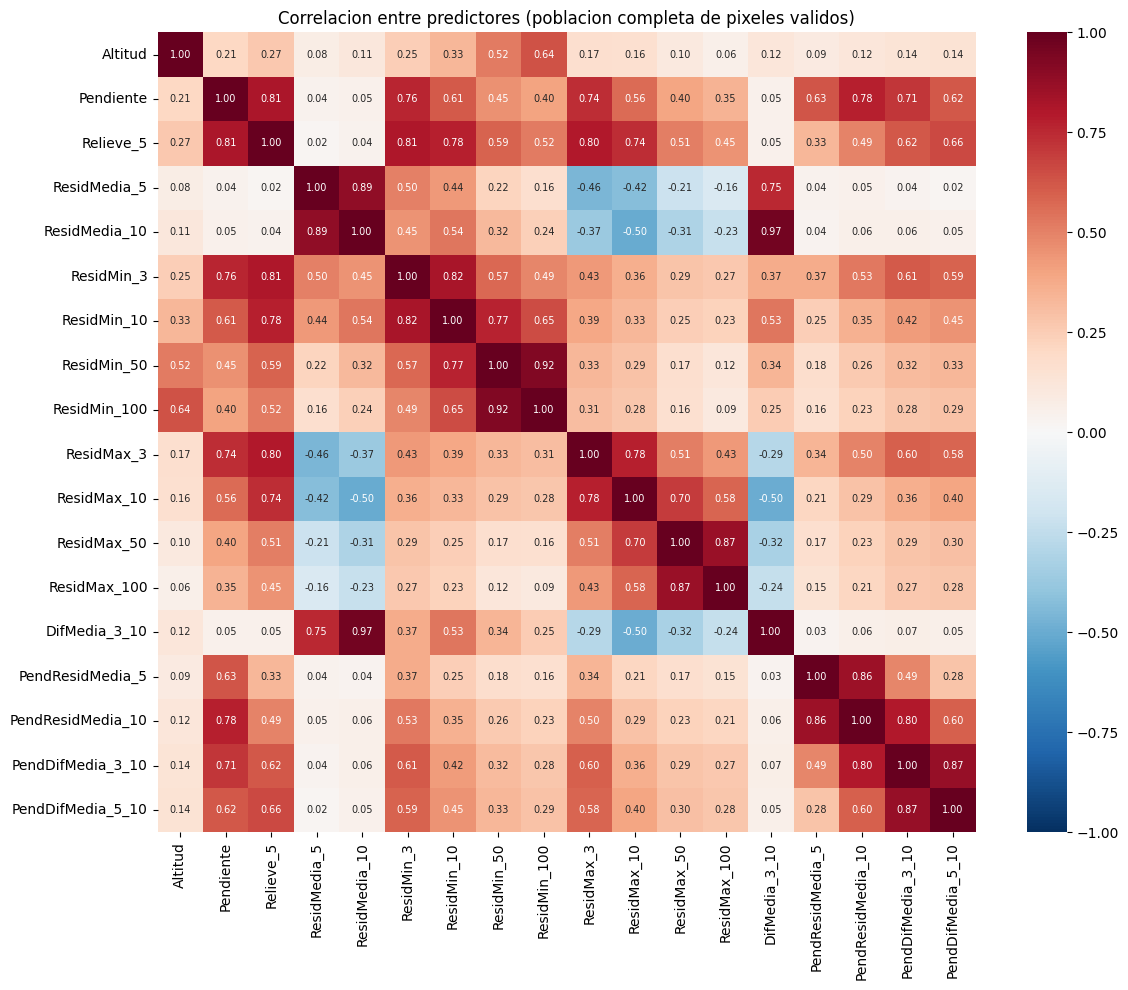

In [7]:
correlacion = tabla[variables_predictoras].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            annot_kws={"size": 7})
plt.title("Correlacion entre predictores (poblacion completa de pixeles validos)")
plt.tight_layout()
plt.savefig(f"{CARPETA_RESULTADOS}\\12_correlacion_predictores_raster.png", dpi=150)
plt.show()


## [7] Factor de Inflación de Varianza (VIF): detectar y resolver colinealidad exacta

**Qué se busca:** el VIF cuantifica cuánta varianza de una variable es
explicada por las DEMÁS variables predictoras (VIF alto = esa variable es
casi una combinación lineal de las otras). Un VIF infinito significa
colinealidad **perfecta** (combinación lineal exacta), lo cual impide que el
optimizador de máxima verosimilitud de la regresión logística converja
correctamente.

**Ventajas / desventajas del VIF:**
- (+) A diferencia de la correlación por pares, sí detecta redundancias que
  involucran combinaciones de tres o más variables.
- (-) Es costoso de calcular con millones de filas (requiere una regresión
  lineal por cada variable contra todas las demás), así que aquí se calcula
  sobre una muestra aleatoria de 50,000 píxeles, suficiente para estimarlo con
  precisión sin recorrer los 25 millones de filas.


In [8]:
muestra_vif = tabla[variables_predictoras].sample(n=50_000, random_state=SEMILLA)
X_vif = sm.add_constant(muestra_vif)

vif_resultado = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_resultado


,variable,VIF
0,const,8.119568
1,Altitud,1.795061
2,Pendiente,9.244856
3,Relieve_5,27.396079
4,ResidMedia_5,33.060844
5,ResidMedia_10,236.465238
6,ResidMin_3,14.161788
7,ResidMin_10,12.243578
8,ResidMin_50,10.787879
9,ResidMin_100,9.339161


**Hallazgo:** al calcular el VIF sobre el listado ORIGINAL de 21 capas
(incluyendo `Relieve_3`, `Relieve_10` y `DifMedia_5_10`, ya excluidas arriba),
varias variables mostraban VIF **infinito**. La causa es una identidad
geomorfométrica exacta: para una misma ventana móvil,

$$\text{Relieve} = \text{ResidMax} + \text{ResidMin}$$

(el relieve local es exactamente la suma de "cuánto sube el terreno sobre el
mínimo" y "cuánto baja respecto al máximo"). Esto ocurre para las ventanas 3 y
10, donde se calcularon las tres variables (Relieve, ResidMin y ResidMax)
simultáneamente. De forma similar, `DifMedia_5_10` es exactamente
`ResidMedia_5 - ResidMedia_10`, ambas ya incluidas como predictores.

Por eso se excluyeron `Relieve_3`, `Relieve_10` y `DifMedia_5_10` del conjunto
de predictores (sección [4]): son matemáticamente redundantes, no aportan
información nueva, y sin quitarlas la regresión logística no converge bien.
El resto de los VIF (varios entre 10 y 30, uno cercano a 230) siguen siendo
altos porque estas variables son, por diseño, todas transformaciones de la
misma superficie de elevación en distintas escalas — se documentan como una
limitación del modelo (afecta la estabilidad/interpretación de los
coeficientes individuales, aunque no necesariamente la capacidad predictiva
global) en vez de seguir eliminando variables de forma indefinida, ya que
esta es una primera aproximación exploratoria.


## [8] Muestreo, división train/test y estandarización

**Qué se busca:** la tabla completa tiene ~25 millones de filas. Ajustar
`statsmodels.Logit` (que calcula la matriz Hessiana completa para la
optimización) sobre ese volumen sería innecesariamente lento para una
PRIMERA aproximación exploratoria, así que se toma una muestra aleatoria de
tamaño manejable (`N_MUESTRA`). La predicción final (sección [11]) sí se
aplica sobre la totalidad de los píxeles válidos, no solo sobre la muestra.

**Ventajas / desventajas de muestrear para el ajuste:**
- (+) Reduce el tiempo de ajuste de minutos/horas a segundos, sin sacrificar
  de forma importante la precisión de los coeficientes (con 300,000
  observaciones el error estándar de los coeficientes ya es muy pequeño).
- (-) Se pierde la posibilidad de detectar patrones muy raros que solo
  aparecen en una fracción diminuta de los 25 millones de píxeles.

Se separa además una partición de **entrenamiento (70%)** y **prueba (30%)**
para evaluar el modelo de forma honesta fuera de muestra (el libro, en su
ejemplo de regresión logística, evalúa sobre los mismos datos de ajuste; aquí
se usa una partición separada por buena práctica, ya que el volumen de datos
lo permite sin sacrificar tamaño de muestra).


In [9]:
muestra = tabla.sample(n=N_MUESTRA, random_state=SEMILLA)
X = muestra[variables_predictoras]
y = muestra["Altiplano"]

print(f"Muestra para ajuste: {len(muestra):,} pixeles. Proporcion Altiplano=1: {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEMILLA, stratify=y
)

escalador = StandardScaler()
X_train_s = escalador.fit_transform(X_train)
X_test_s = escalador.transform(X_test)

print(f"Entrenamiento: {len(X_train):,} filas. Prueba: {len(X_test):,} filas.")


Muestra para ajuste: 300,000 pixeles. Proporcion Altiplano=1: 15.1%


Entrenamiento: 210,000 filas. Prueba: 90,000 filas.


## [9] Modelo interpretable: regresión logística con `statsmodels`

**Qué se busca:** obtener el resumen estadístico completo del modelo
(coeficientes, significancia, Pseudo R², prueba de razón de verosimilitud),
igual que en el ejemplo de susceptibilidad a movimientos en masa del libro
(`04_GLMPhyton`).

**Interpretación del "R²" pedido:** en una regresión logística no existe un
R² en el sentido clásico de OLS (no hay una "suma de cuadrados residual"
comparable). El libro reporta en su lugar el **Pseudo R² de McFadden**
(`prsquared` en `statsmodels`), que compara la verosimilitud del modelo
ajustado contra la de un modelo nulo (solo intercepto). Se interpreta en una
escala distinta a un R² de OLS: valores de 0.2-0.4 ya se consideran un ajuste
excelente en la literatura de McFadden (valores mucho más altos que en OLS
NO son directamente comparables).


In [10]:
X_train_sm = sm.add_constant(X_train_s)
modelo_logit = sm.Logit(y_train.values, X_train_sm).fit(disp=0)

print(modelo_logit.summary(xname=["const"] + variables_predictoras))


                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               210000
Model:                          Logit   Df Residuals:                   209981
Method:                           MLE   Df Model:                           18
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.5514
Time:                        05:50:41   Log-Likelihood:                -39948.
converged:                       True   LL-Null:                       -89056.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -5.1987      0.030   -174.019      0.000      -5.257      -5.140
Altitud               1.1472      0.012     99.596      0.000       1.125       1.170
Pendiente            -0.

**Advertencia detectada en la salida de `statsmodels` (importante):**
`Possibly complete quasi-separation: A fraction 0.20 of observations can be
perfectly predicted.` Esto significa que, para aproximadamente el 20% de los
píxeles de la muestra de entrenamiento, la combinación de predictores permite
clasificarlos con una certeza casi perfecta (probabilidad muy cercana a 0 o a
1). Es coherente con el AUC muy alto (0.95) obtenido más adelante, pero tiene
una implicación estadística: cuando hay cuasi-separación, los errores
estándar de algunos coeficientes (y por lo tanto sus valores p) dejan de ser
totalmente confiables, aunque el modelo siga siendo útil para **predecir**.
Por eso las conclusiones de este notebook se apoyan en las métricas de
predicción (Pseudo R², AUC, matriz de confusión) más que en la significancia
individual de cada coeficiente.


In [11]:
print(f"Pseudo R2 (McFadden): {modelo_logit.prsquared:.4f}")
print(f"Log-Likelihood: {modelo_logit.llf:.1f}")
print(f"LLR p-value (vs. modelo nulo): {modelo_logit.llr_pvalue:.3e}")


Pseudo R2 (McFadden): 0.5514
Log-Likelihood: -39948.3
LLR p-value (vs. modelo nulo): 0.000e+00


## [10] Modelo de clasificación: `sklearn` (matriz de confusión, ROC, AUC)

**Qué se busca:** las mismas métricas de evaluación de clasificación binaria
que usa el libro en su ejemplo de regresión logística: matriz de confusión,
reporte de clasificación (precisión/recall/F1) y curva ROC con su AUC.


In [12]:
modelo_sk = LogisticRegression(max_iter=1000)
modelo_sk.fit(X_train_s, y_train)

y_pred = modelo_sk.predict(X_test_s)
y_prob = modelo_sk.predict_proba(X_test_s)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nMatriz de confusion:")
matriz_conf = confusion_matrix(y_test, y_pred)
print(matriz_conf)
print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred, target_names=["No altiplano", "Altiplano"]))


Accuracy: 0.9124

Matriz de confusion:
[[73359  3070]
 [ 4817  8754]]

Reporte de clasificacion:
              precision    recall  f1-score   support

No altiplano       0.94      0.96      0.95     76429
   Altiplano       0.74      0.65      0.69     13571

    accuracy                           0.91     90000
   macro avg       0.84      0.80      0.82     90000
weighted avg       0.91      0.91      0.91     90000



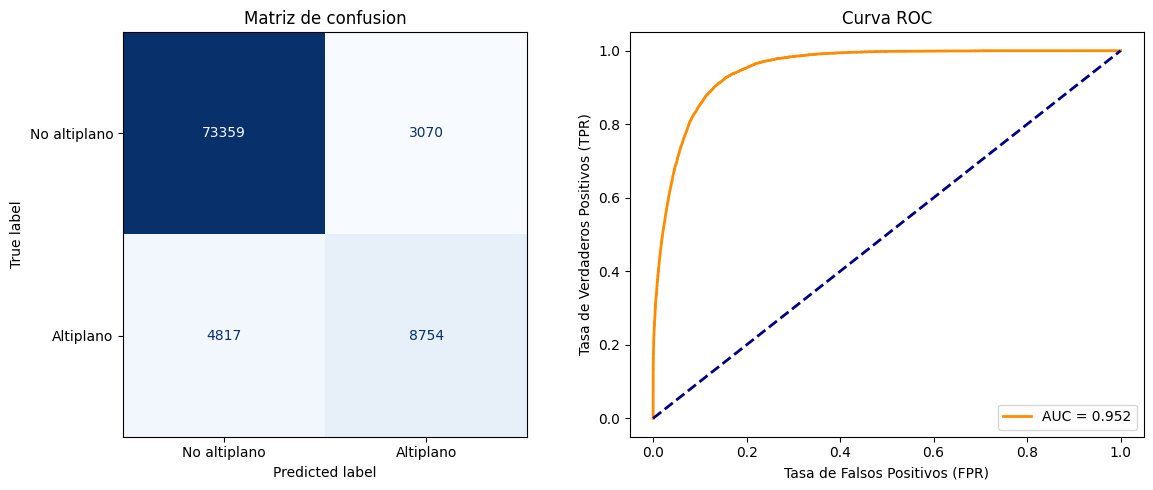

AUC-ROC: 0.9522


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=matriz_conf, display_labels=["No altiplano", "Altiplano"]).plot(
    ax=ax1, cmap="Blues", colorbar=False
)
ax1.set_title("Matriz de confusion")

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
ax2.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f}")
ax2.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax2.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax2.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax2.set_title("Curva ROC")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.savefig(f"{CARPETA_RESULTADOS}\\13_matriz_confusion_roc.png", dpi=150)
plt.show()

print(f"AUC-ROC: {auc:.4f}")


## [11] Predicción sobre toda el área de estudio: mapa de probabilidad

**Qué se busca:** aplicar el modelo ajustado a **todos** los píxeles válidos
del área de estudio (no solo a la muestra de entrenamiento/prueba) para
generar un mapa continuo de probabilidad de ser altiplano, igual que el
"Mapa de Probabilidad de Movimiento en Masa" del notebook `04_GLMPhyton`.
Gracias a que la regresión logística es un modelo simple (una combinación
lineal + función logística), predecir sobre los ~25 millones de píxeles es
casi instantáneo.


In [14]:
t_pred = time.time()

X_todos = tabla[variables_predictoras]
X_todos_s = escalador.transform(X_todos)
prob_todos = modelo_sk.predict_proba(X_todos_s)[:, 1]

print(f"Prediccion sobre {len(X_todos):,} pixeles en {time.time()-t_pred:.1f} s")

mapa_probabilidad = np.full(ref_shape, np.nan, dtype=np.float32)
mapa_probabilidad.ravel()[idx_validos] = prob_todos

print(f"Rango de probabilidad predicha: {np.nanmin(mapa_probabilidad):.3f} - {np.nanmax(mapa_probabilidad):.3f}")


Prediccion sobre 24,783,966 pixeles en 18.4 s


Rango de probabilidad predicha: 0.000 - 0.998


**Comparación con los polígonos originales:** se superpone la capa
`Clusters.shp` (los 491 polígonos de altiplano delimitados a mano, usados en
`01_clustering_altiplanos.py`/`02_clustering_espacial_altiplanos.py`) sobre el
mapa de probabilidad, mostrando **solo el borde** (`facecolor="none"`) para no
tapar el mapa de calor. Esto permite comparar visualmente qué tan bien la
predicción de la regresión (sin ninguna referencia directa a los polígonos)
recupera la ubicación de los altiplanos ya conocidos.


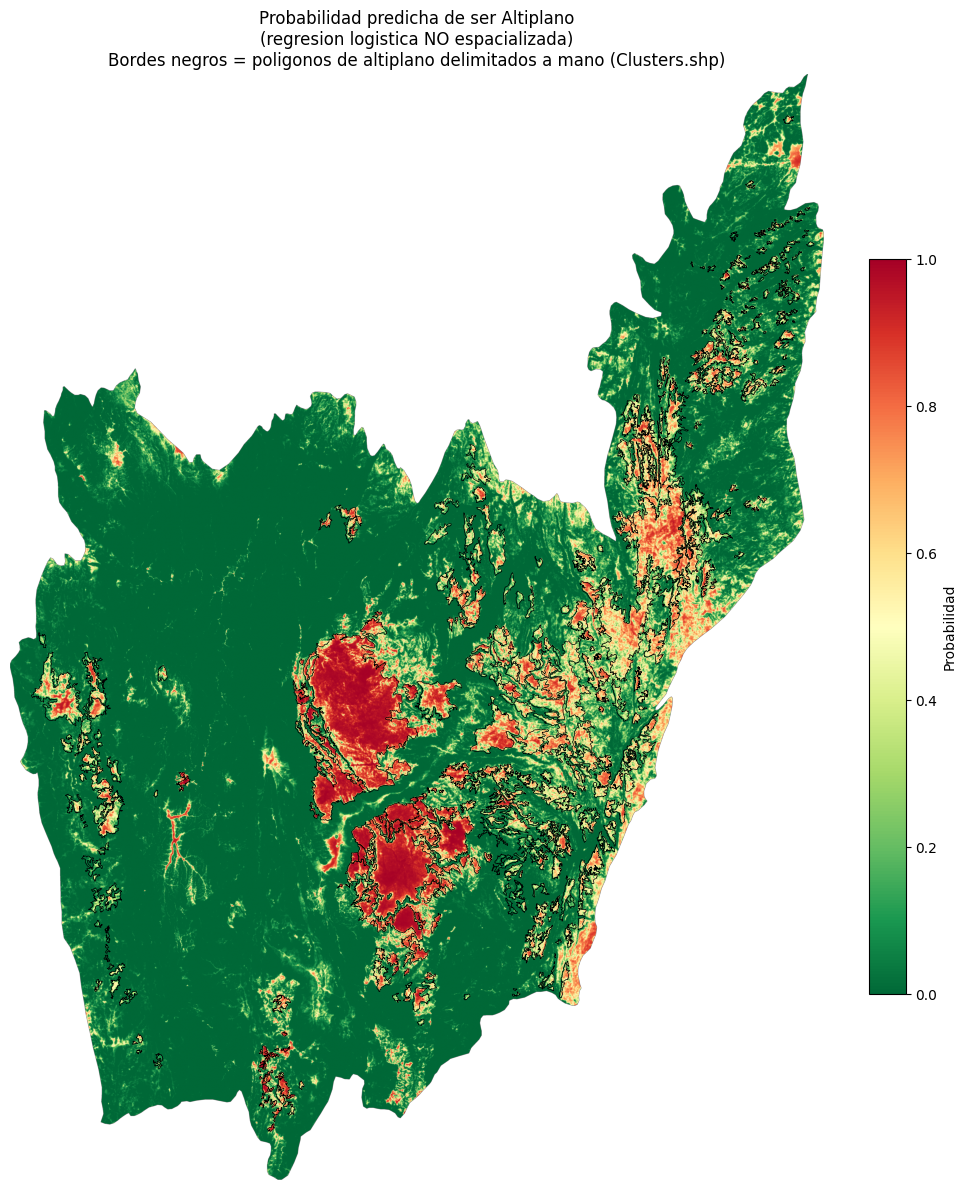

In [15]:
# Poligonos originales delimitados a mano (Clusters.shp), para comparar
# visualmente contra la prediccion. Se grafica SOLO el borde (.boundary,
# facecolor="none") para no tapar el mapa de probabilidad de abajo.
poligonos_originales = gpd.read_file(r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Clusters.shp")
if poligonos_originales.crs != ref_crs:
    poligonos_originales = poligonos_originales.to_crs(ref_crs)

# extent en coordenadas reales (no en indices de fila/columna) para que el
# imshow y los poligonos de geopandas queden perfectamente alineados
izquierda, abajo, derecha, arriba = array_bounds(ref_shape[0], ref_shape[1], ref_transform)

fig, ax = plt.subplots(figsize=(10, 12))
im = ax.imshow(mapa_probabilidad, cmap="RdYlGn_r", vmin=0, vmax=1,
               extent=(izquierda, derecha, abajo, arriba))
poligonos_originales.boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)
ax.set_title("Probabilidad predicha de ser Altiplano\n(regresion logistica NO espacializada)\n"
             "Bordes negros = poligonos de altiplano delimitados a mano (Clusters.shp)")
ax.set_axis_off()
plt.colorbar(im, ax=ax, label="Probabilidad", fraction=0.04)
plt.tight_layout()
plt.savefig(f"{CARPETA_RESULTADOS}\\14_mapa_probabilidad_altiplano.png", dpi=150)
plt.show()

**Exportar el mapa de probabilidad como GeoTIFF**, para poder abrirlo
en ArcGIS/QGIS junto con las demás capas del proyecto.


In [16]:
perfil_salida = {
    "driver": "GTiff",
    "height": ref_shape[0],
    "width": ref_shape[1],
    "count": 1,
    "dtype": "float32",
    "crs": ref_crs,
    "transform": ref_transform,
    "nodata": np.nan,
    "compress": "lzw",
}

ruta_salida_raster = f"{CARPETA_RESULTADOS}\\probabilidad_altiplano.tif"
with rasterio.open(ruta_salida_raster, "w", **perfil_salida) as dst:
    dst.write(mapa_probabilidad, 1)

print(f"Mapa de probabilidad guardado en: {ruta_salida_raster}")
print(f"\nTIEMPO TOTAL DEL NOTEBOOK: {time.time()-t_inicio:.1f} s")


Mapa de probabilidad guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\probabilidad_altiplano.tif

TIEMPO TOTAL DEL NOTEBOOK: 199.3 s


## Conclusiones y siguientes pasos

- El modelo (18 predictores geomorfométricos, sin ninguna variable espacial)
  alcanza un **Pseudo R² de McFadden** y un **AUC** que indican una capacidad
  discriminante muy alta entre píxeles de altiplano y no-altiplano usando
  solo variables de forma del terreno.
- La matriz de correlación y, sobre todo, el **VIF** muestran que estas
  variables geomorfométricas están fuertemente correlacionadas entre sí (por
  construcción, todas derivan de la misma superficie de elevación en
  distintas ventanas); esto no invalida la predicción, pero sí advierte que
  los coeficientes individuales del modelo deben interpretarse con cautela.
- **Limitación central de este notebook:** al ser una regresión NO
  espacializada, el modelo ignora que los píxeles de altiplano tienden a
  agruparse geográficamente (autocorrelación espacial). Dos líneas de trabajo
  natural para continuar:
  1. Diagnosticar autocorrelación espacial en los **residuos** del modelo
     (equivalente en ráster al análisis de `07_MatrizCorrelacion` /
     `09_SpatialRegression` del libro, adaptado a datos de grilla regular).
  2. Considerar modelos espaciales explícitos (SAR/CAR del libro, o un GLM
     con un termino de autocorrelacion) si los residuos muestran patrón
     espacial significativo.
